# Autonomous Ship Motion Control in 3-DoF
**Authors:** Martina De Angelis (r1125657), Seppe Hermans (r0939189)

AI tools were used as a coding assistant for syntax and debugging.

## Project Overview
This notebook explores the planar motion of a surface vessel in 3 Degrees of Freedom (Surge, Sway, and Yaw) using the Fossen maneuvering model.

We will simulate the ship's non-linear dynamics, introduce environmental disturbances (wind and ocean currents), linearize the system around an equilibrium point, and design multiple control strategies (PID, LQR, and MPC) to execute a 20/20 Zig-Zag maneuver.

### System Initialization
First, we import the necessary libraries and define the non-dimensional constants and physical parameters provided for the vessel.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import control as cnt
from scipy.linalg import solve_continuous_are, solve_discrete_are

# General constants
m_prime = 40
Iz_prime = 8.0
KT_prime = 0.161
Dp_prime = 1.53

# Surge constants
Xu_dot_prime = -1.42
Xu_prime = 0.1
Xuu_prime = 8.2
X_G_prime = 0.0

# Sway constants
Yv_dot_prime = -38.4
Yr_dot_prime = -2.5
Yv_prime = 10
Yr_prime = 5
Yvv_prime = 200
Yvr_prime = 0

# Yaw constants
Nr_dot_prime = -8.9
Nv_dot_prime = 2.2
Nv_prime = 36
Nr_prime = 5
Nrr_prime = 15
Nvv_prime = 0
Nvr_prime = 0

# Rudder control derivatives
Y_delta_prime = 1.0
N_delta_prime = 1.0

# Physical constants
rho = 1.025  # t/m³
L = 10       # m
U = 2        # m/s

# Utility function for environmental vectors
def vec_from_mag_dir(magnitude, direction_deg):
    angle = np.deg2rad(direction_deg)
    return np.array([
        magnitude * np.cos(angle),
        magnitude * np.sin(angle)
    ])

# Environment settings dictionary
env = {
    "current_speed": 1,
    "current_dir_deg": 90,
    "wind_force": 0.0,
    "wind_dir_deg": 0.0,
    "wind_yaw_arm": 0.0,
    "current_speed_amp": 0.2,
    "current_speed_freq": 0.05,
    "wind_force_amp": 0.0,
    "wind_force_freq": 0
}

## 1. Non-linear ODE Simulation with Environmental Effects

The ship's motion is governed by the Fossen equation:
$$M\dot{\nu} + C(\nu)\nu + D(\nu)\nu = \tau_{control} + \tau_{env}$$

Where $M$ is the inertia matrix, $C(\nu)$ is the Coriolis-centripetal matrix, $D(\nu)$ is the damping matrix, and $\tau$ represents forces and moments. We expand this to include environmental disturbances such as ocean currents and wind force. 

Below, we define the non-linear ordinary differential equations (ODEs) and simulate an open-loop maneuver from a stationary state to observe the baseline dynamics.

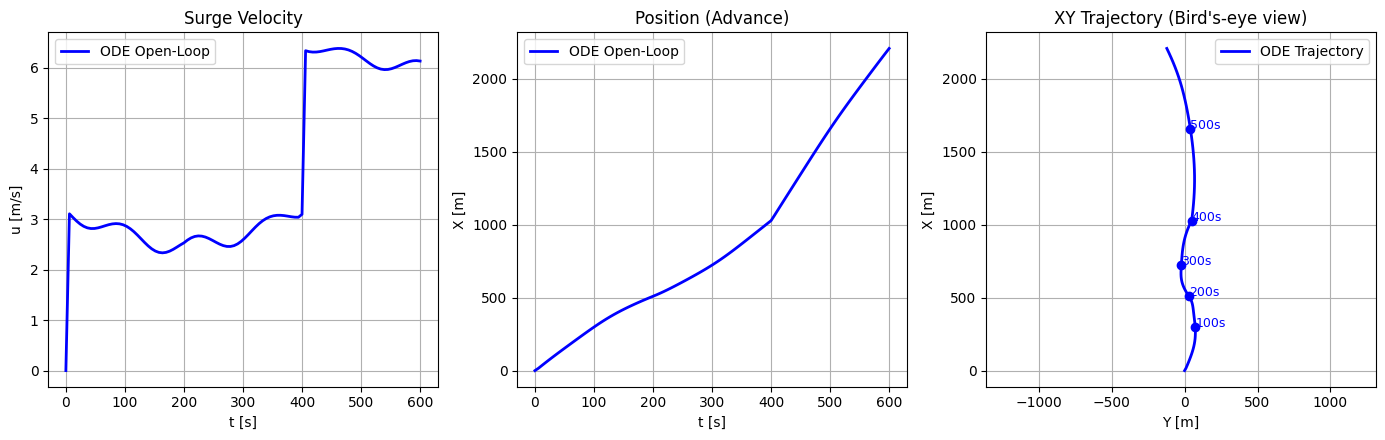

In [2]:
def ship_ode(t, state):
    u, v, r, x, y, psi = state
    nu = np.array([u, v, r])

    # Simple open-loop control sequence
    if t < 200:
        n_eff = 10
        delta_eff = np.deg2rad(45)
    elif t < 400:
        n_eff = 10
        delta_eff = np.deg2rad(-45)
    else:
        n_eff = 20
        delta_eff = np.deg2rad(45)

    tau_1 = rho * n_eff ** 2 * Dp_prime ** 4 * KT_prime
    tau_2 = -Y_delta_prime * delta_eff
    tau_3 = -N_delta_prime * delta_eff
    tau_control = np.array([tau_1, tau_2, tau_3])

    R = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi),  np.cos(psi), 0],
        [0,            0,           1]
    ])

    # Environmental Effects: Current
    current_speed = env["current_speed"] + env["current_speed_amp"] * np.sin(env["current_speed_freq"] * t)
    current_xy_earth = vec_from_mag_dir(current_speed, env["current_dir_deg"])
    v_current_earth = np.array([current_xy_earth[0], current_xy_earth[1], 0.0])

    nu_c_body = R.T @ v_current_earth
    nu_r = nu - nu_c_body
    u_r, v_r, r_r = nu_r

    # Environmental Effects: Wind
    wind_force = env["wind_force"] + env["wind_force_amp"] * np.sin(env["wind_force_freq"] * t)
    wind_xy_earth = vec_from_mag_dir(wind_force, env["wind_dir_deg"])
    tau_wind_earth = np.array([wind_xy_earth[0], wind_xy_earth[1], 0.0])
    tau_wind_body = R.T @ tau_wind_earth
    
    X_wind = tau_wind_body[0]
    Y_wind = tau_wind_body[1]
    N_wind = env["wind_yaw_arm"] * Y_wind
    tau_env = np.array([X_wind, Y_wind, N_wind])

    # Matrices Assembly
    M_matrix = np.array([
        [m_prime - Xu_dot_prime, 0, 0],
        [0, m_prime - Yv_dot_prime, -Yr_dot_prime],
        [0, -Nv_dot_prime, Iz_prime - Nr_dot_prime]
    ])

    N11 = Xu_prime + Xuu_prime * np.abs(u_r)
    N22 = Yv_prime + Yvv_prime * np.abs(v_r)
    N23 = (m_prime - Xu_dot_prime) * u_r + Yr_prime * np.abs(v_r)
    N32 = -(m_prime - Xu_dot_prime) * u_r + Nv_prime * np.abs(v_r)
    N33 = Nr_prime + Nrr_prime * np.abs(r_r)

    N_matrix = np.array([
        [N11, 0, 0],
        [0, N22, N23],
        [0, N32, N33]
    ])

    eta_dot = R @ nu + v_current_earth
    nu_dot = np.linalg.solve(M_matrix, tau_control + tau_env - N_matrix @ nu_r)

    return np.concatenate((nu_dot, eta_dot))

# Initial condition and simulation
state0 = np.array([0, 0, 0, 0, 0, 0])
time_sim_end = 600
TSPAN = [0, time_sim_end]

sol = solve_ivp(ship_ode, TSPAN, state0, dense_output=True, max_step=0.1)
t = np.linspace(0, time_sim_end, 100)
u_traj, v_traj, r_traj, x_traj, y_traj, psi_traj = sol.sol(t)

# Plotting Open-Loop Dynamics
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(14, 4.5))
ax0, ax1, ax2 = axs

ax0.plot(t, u_traj, label='ODE Open-Loop', color='b', linewidth=2)
ax0.set(xlabel='t [s]', ylabel='u [m/s]', title='Surge Velocity')
ax0.legend(); ax0.grid()

ax1.plot(t, x_traj, label='ODE Open-Loop', color='b', linewidth=2)
ax1.set(xlabel='t [s]', ylabel='X [m]', title='Position (Advance)')
ax1.legend(); ax1.grid()

t_marks = np.array([100, 200, 300, 400, 500])
marks = sol.sol(t_marks)
ax2.plot(y_traj, x_traj, label='ODE Trajectory', color='b', linewidth=2)
ax2.scatter(marks[4, :], marks[3, :], color='blue', zorder=3)
for i, tm in enumerate(t_marks):
    ax2.text(marks[4, i] + 0.5, marks[3, i], f'{tm}s', fontsize=9, color='blue')

ax2.set(xlabel='Y [m]', ylabel='X [m]', title='XY Trajectory (Bird\'s-eye view)')
ax2.axis('equal'); ax2.legend(); ax2.grid()
fig.tight_layout()
plt.show()

## 2. System Linearization

To apply advanced control theories like LQR and MPC, we must linearize our highly non-linear Fossen model around a steady-state equilibrium point. We choose a forward cruising speed of **2 m/s** ($u_0 = 2$). 

We utilize the `sympy` library to calculate the analytical Jacobians for the states ($A$ matrix) and inputs ($B$ matrix). We also solve for the equilibrium propeller speed ($n_0$) required to maintain this forward speed.

In [3]:
u_s, v_s, r_s = sp.symbols('u v r', real=True)
delta_s = sp.symbols('delta', real=True)
n_s = sp.symbols('n', positive=True)

M = sp.Matrix([
    [m_prime - Xu_dot_prime, 0, 0],
    [0, m_prime - Yv_dot_prime, -Yr_dot_prime],
    [0, -Nv_dot_prime, Iz_prime - Nr_dot_prime],
])

N11_s = Xu_prime + Xuu_prime * sp.sqrt(u_s ** 2)
N22_s = Yv_prime + Yvv_prime * sp.sqrt(v_s ** 2)
N23_s = (m_prime - Xu_dot_prime) * u_s + Yr_prime * sp.sqrt(v_s ** 2)
N32_s = -(m_prime - Xu_dot_prime) * u_s + Nv_prime * sp.sqrt(v_s ** 2)
N33_s = Nr_prime + Nrr_prime * sp.sqrt(r_s ** 2)

N = sp.Matrix([
    [N11_s, 0, 0],
    [0, N22_s, N23_s],
    [0, N32_s, N33_s],
])

tau1 = rho * n_s ** 2 * Dp_prime ** 4 * KT_prime
tau2 = -Y_delta_prime * delta_s
tau3 = -N_delta_prime * delta_s
tau = sp.Matrix([tau1, tau2, tau3])

nu_vec = sp.Matrix([u_s, v_s, r_s])
nu_dot_sym = M.inv() * (tau - N * nu_vec)

# Solve surge equation for n0
u0 = 2
nu_dot_eq = nu_dot_sym.subs({u_s: u0, v_s: 0, r_s: 0, delta_s: 0})
n0_sols = sp.solve(nu_dot_eq[0], n_s)
n0_val = [s for s in n0_sols if s.is_real and s > 0][0]
print(f"Equilibrium propeller speed: n0 ≈ {float(n0_val.evalf()):.4f} rps")

# Jacobians
state_vec_s = sp.Matrix([u_s, v_s, r_s])
input_vec_s = sp.Matrix([delta_s, n_s])

A_sym = nu_dot_sym.jacobian(state_vec_s)
B_sym = nu_dot_sym.jacobian(input_vec_s)

subs_eq = {u_s: u0, v_s: 0, r_s: 0, delta_s: 0, n_s: n0_val}
A = np.array(sp.N(A_sym.subs(subs_eq)), dtype=float)
B = np.array(sp.N(B_sym.subs(subs_eq)), dtype=float)

print("\nA matrix (3 states x 3 states):")
print(A)
print("\nB matrix (3 states x 2 inputs):")
print(B)

Equilibrium propeller speed: n0 ≈ 6.0409 rps

A matrix (3 states x 3 states):
[[-0.79430227  0.          0.        ]
 [ 0.         -0.28268418 -1.04286938]
 [ 0.          4.86497602 -0.43161613]]

B matrix (3 states x 2 inputs):
[[ 0.          0.26377559]
 [-0.01082332  0.        ]
 [-0.06058055  0.        ]]


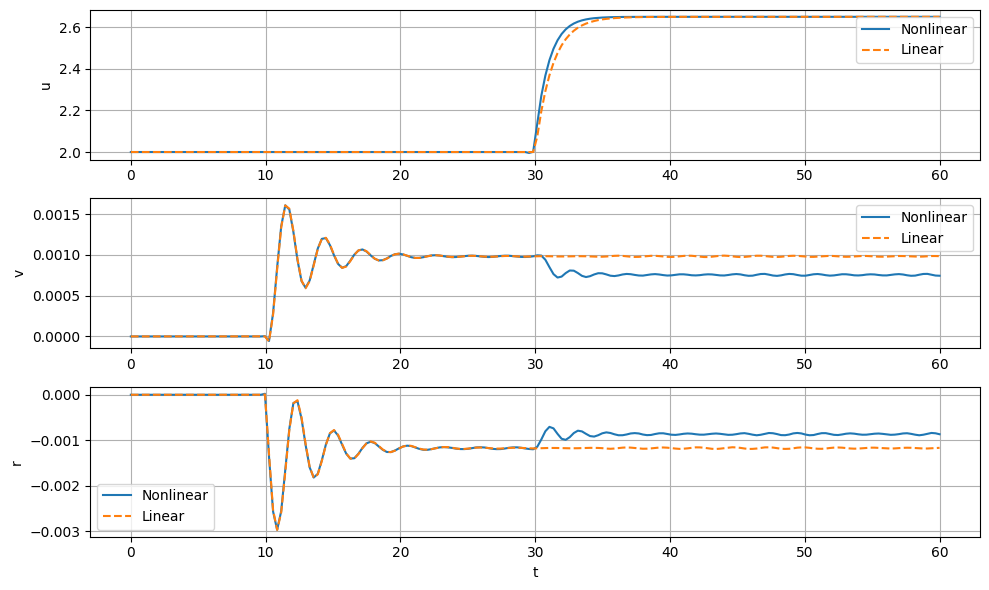

In [4]:
# ================================
# COMPARISON: NONLINEAR vs LINEAR
# ================================

# same input for both models
def control_input(t):
    # Rudder step
    if t < 10:
        delta = 0
    elif t < 20:
        delta = np.deg2rad(5)
    else:
        delta = np.deg2rad(5)
    # Propeller speed variation
    if t < 30:
        n = 6.0409
    else:
        n = 8  # step up
    return delta, n

# -------- NONLINEAR MODEL --------
def ship_ode_input(t, state):
    u, v, r, x, y, psi = state
    delta, n = control_input(t)

    tau_1 = rho * n ** 2 * Dp_prime ** 4 * KT_prime
    tau_2 = -Y_delta_prime * delta
    tau_3 = -N_delta_prime * delta
    tau_control = np.array([tau_1, tau_2, tau_3])

    nu = np.array([u, v, r])

    M_matrix = np.array([
        [m_prime - Xu_dot_prime, 0, 0],
        [0, m_prime - Yv_dot_prime, -Yr_dot_prime],
        [0, -Nv_dot_prime, Iz_prime - Nr_dot_prime]
    ])

    N11 = Xu_prime + Xuu_prime * np.abs(u)
    N22 = Yv_prime + Yvv_prime * np.abs(v)
    N23 = (m_prime - Xu_dot_prime) * u + Yr_prime * np.abs(v)
    N32 = -(m_prime - Xu_dot_prime) * u + Nv_prime * np.abs(v)
    N33 = Nr_prime + Nrr_prime * np.abs(r)

    N_matrix = np.array([
        [N11, 0, 0],
        [0, N22, N23],
        [0, N32, N33]
    ])

    nu_dot = np.linalg.solve(M_matrix, tau_control - N_matrix @ nu)

    return np.concatenate((nu_dot, [0, 0, 0]))


# -------- LINEAR MODEL --------
def linear_model(t, x):
    delta, n = control_input(t)
    u_input = np.array([delta, n]) - np.array([0, float(n0_val)])
    return A @ x + B @ u_input


# -------- SIMULATION --------
t_eval = np.linspace(0, 60, 200)

# Nonlinear
state0_nl = np.array([u0, 0, 0, 0, 0, 0])
sol_nl = solve_ivp(ship_ode_input, [0, 60], state0_nl, t_eval=t_eval)

# Linear (start in deviation = 0)
x0_lin = np.array([0, 0, 0])
sol_lin = solve_ivp(linear_model, [0, 60], x0_lin, t_eval=t_eval)

# Back to absolute values
u_nl, v_nl, r_nl = sol_nl.y[0], sol_nl.y[1], sol_nl.y[2]
u_lin = sol_lin.y[0] + u0
v_lin = sol_lin.y[1]
r_lin = sol_lin.y[2]


# -------- PLOT --------
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.plot(t_eval, u_nl, label='Nonlinear')
plt.plot(t_eval, u_lin, '--', label='Linear')
plt.ylabel('u')
plt.legend(); plt.grid()

plt.subplot(3,1,2)
plt.plot(t_eval, v_nl, label='Nonlinear')
plt.plot(t_eval, v_lin, '--', label='Linear')
plt.ylabel('v')
plt.legend(); plt.grid()

plt.subplot(3,1,3)
plt.plot(t_eval, r_nl, label='Nonlinear')
plt.plot(t_eval, r_lin, '--', label='Linear')
plt.ylabel('r')
plt.xlabel('t')
plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

## 3. Controller Design

We want the ship to perform a **20/20 Zig-Zag maneuver**. We will compare three distinct controllers:
1. **LQR with Luenberger Observer:** Optimal state feedback, combined with an observer to estimate unmeasured states amidst sensor noise.
2. **PID Controller:** A classical SISO approach designed via the transfer function and Root Locus analysis, equipped with a low-pass filter and anti-windup.
3. **Model Predictive Control (MPC):** An advanced constrained optimization algorithm that looks ahead over a prediction horizon ($N_p$) to calculate the optimal control inputs while respecting actuator constraints.

In [5]:
# CONTROLLABILITY / OBSERVABILITY
C_ctrl = np.array([
    [1, 0, 0],
    [0, 0, 1]
])
D_ctrl = np.zeros((2, 2))

def check_system(A, B, C):
    Co = cnt.ctrb(A, B)
    Obs = cnt.obsv(A, C)

    n = A.shape[0]
    rank_ctrb = np.linalg.matrix_rank(Co)
    rank_obsv = np.linalg.matrix_rank(Obs)

    return {
        "controllability_matrix": Co,
        "observability_matrix": Obs,
        "rank_ctrb": rank_ctrb,
        "rank_obsv": rank_obsv,
        "uncontrollable_modes": n - rank_ctrb,
        "unobservable_modes": n - rank_obsv,
        "is_controllable": rank_ctrb == n,
        "is_observable": rank_obsv == n,
    }
sys_check = check_system(A, B, C_ctrl)
print(f"Controllable: {sys_check['is_controllable']} | Observable: {sys_check['is_observable']}")

# ============================================================
# COMMON UTILITIES
# ============================================================

def bryson_weights(x_max, u_max, q_priority=None, r_priority=None):
    x_max = np.asarray(x_max, dtype=float)
    u_max = np.asarray(u_max, dtype=float)

    if q_priority is None:
        q_priority = np.ones_like(x_max)
    if r_priority is None:
        r_priority = np.ones_like(u_max)

    q_priority = np.asarray(q_priority, dtype=float)
    r_priority = np.asarray(r_priority, dtype=float)

    Q = np.diag(q_priority / (x_max ** 2))
    R = np.diag(r_priority / (u_max ** 2))
    return Q, R


def solve_lqr(A, B, Q, R):
    P = solve_continuous_are(A, B, Q, R)
    K = np.linalg.solve(R, B.T @ P)
    eig_cl = np.linalg.eigvals(A - B @ K)
    return K, P, eig_cl


def quadratic_cost(X, U, Q, R, dt):
    x_cost = np.einsum("bi,ij,bj->b", X, Q, X)
    u_cost = np.einsum("bi,ij,bj->b", U, R, U)

    Jx = np.sum(x_cost) * dt
    Ju = np.sum(u_cost) * dt
    J = Jx + Ju
    return J, Jx, Ju


def tracking_cost_from_history(states, r_ref_hist, delta_hist, n_hist, Q, R, dt, u0=2.0, n0=0.0):
    x_err = np.column_stack([
        states[:, 0] - u0,
        states[:, 1],
        states[:, 2] - r_ref_hist
    ])

    u_dev = np.column_stack([
        delta_hist,
        n_hist - n0
    ])

    return quadratic_cost(x_err, u_dev, Q, R, dt)


Controllable: True | Observable: True


### LQR Controller

In [6]:
# pole placement

P_pp = np.array([-0.5, -1.0, -1.5])
K_pp = cnt.place(A, B, P_pp)

#observer

P_obs = 3.0 * P_pp
L_obs = cnt.place(A.T, C_ctrl.T, P_obs).T



u_dev_max = 0.50
v_max = 0.3
r_max = np.deg2rad(10.0)

delta_max = np.deg2rad(35.0)
dn_max = 5.0

x_max = np.array([u_dev_max, v_max, r_max])
u_max = np.array([delta_max, dn_max])

q_priority = np.array([1.0, 1.0, 100.0])
r_priority = np.array([1.0, 1.0])

Q_lqr, R_lqr = bryson_weights(x_max, u_max, q_priority, r_priority)
K_lqr, P_lqr, eig_cl_lqr = solve_lqr(A, B, Q_lqr, R_lqr)

### MPC Controller

In [7]:
def build_prediction_matrices(Ad, Bd, Np):
    nx, nu = Ad.shape[0], Bd.shape[1]
    Phi = np.zeros((Np * nx, nx))
    Gamma = np.zeros((Np * nx, Np * nu))

    for i in range(Np):
        Phi[i * nx:(i + 1) * nx, :] = np.linalg.matrix_power(Ad, i + 1)
        for j in range(i + 1):
            Gamma[i * nx:(i + 1) * nx, j * nu:(j + 1) * nu] = (
                np.linalg.matrix_power(Ad, i - j) @ Bd
            )

    return Phi, Gamma


def mpc_control(x0, x_ref, Ad, Bd, Q, R, P, Np, umin, umax):
    nx, nu = Ad.shape[0], Bd.shape[1]
    Phi, Gamma = build_prediction_matrices(Ad, Bd, Np)

    Qbar = np.block([
        [np.kron(np.eye(Np - 1), Q), np.zeros(((Np - 1) * nx, nx))],
        [np.zeros((nx, (Np - 1) * nx)), P]
    ])
    Rbar = np.kron(np.eye(Np), R)
    Xref = np.tile(x_ref, Np)

    H = Gamma.T @ Qbar @ Gamma + Rbar
    f = Gamma.T @ Qbar @ (Phi @ x0 - Xref)

    U_seq = -np.linalg.solve(H + 1e-9 * np.eye(H.shape[0]), f)
    return np.clip(U_seq[:nu], umin, umax)


dt_mpc = 0.1
sysd_mpc = cnt.c2d(
    cnt.ss(A, B, np.eye(A.shape[0]), np.zeros((A.shape[0], B.shape[1]))),
    dt_mpc
)

Ad = np.array(sysd_mpc.A)
Bd = np.array(sysd_mpc.B)

Np = 20
Q_mpc = Q_lqr.copy()
R_mpc = R_lqr.copy()
P_mpc = solve_discrete_are(Ad, Bd, Q_mpc, R_mpc)

umin_mpc = np.array([
    -np.deg2rad(35.0),
    -float(n0_val) + 0.1
])

umax_mpc = np.array([
    np.deg2rad(35.0),
    10.0
])

### PID Controller Tuning via Root Locus
For the PID, we isolate the SISO path linking the rudder ($\delta$) to the yaw rate ($r$), and add an integrator to track the heading ($\psi$).

In [8]:
# TRANSFER FUNCTIONS
s = sp.symbols('s')

# Convert A and B to SymPy matrices
A_sp = sp.Matrix(A)
B_sp = sp.Matrix(B)

# Transfer matrix: G(s) = (sI - A)^(-1) B
# outputs = [u, v, r], inputs = [delta, n]
G = sp.simplify((s * sp.eye(3) - A_sp).inv() * B_sp)

state_names = ['u', 'v', 'r']
input_names = ['delta', 'n']

print("\nTransfer functions (linearized around equilibrium):")
for i, y_name in enumerate(state_names):
    for j, u_name in enumerate(input_names):
        Gij = sp.together(sp.simplify(G[i, j]))
        print(f"\n{y_name}(s) / {u_name}(s) =")
        sp.pprint(Gij, use_unicode=True)
        print()


Transfer functions (linearized around equilibrium):

u(s) / delta(s) =
0


u(s) / n(s) =
                      2                                             
   0.263775590166827⋅s  + 0.188414987721437⋅s + 1.37045810708168    
────────────────────────────────────────────────────────────────────
     3                     2                                        
1.0⋅s  + 1.50860258661859⋅s  + 5.76291596376672⋅s + 4.12683366164466


v(s) / delta(s) =
                       2                                            
 - 0.0108233242637885⋅s  + 0.0499090895781423⋅s + 0.04647151259927  
────────────────────────────────────────────────────────────────────
     3                     2                                        
1.0⋅s  + 1.50860258661859⋅s  + 5.76291596376672⋅s + 4.12683366164466


v(s) / n(s) =
0


r(s) / delta(s) =
                       2                                            
 - 0.0605805510875938⋅s  - 0.117899645924316⋅s - 0.0554267115842269 
────────────────────────

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


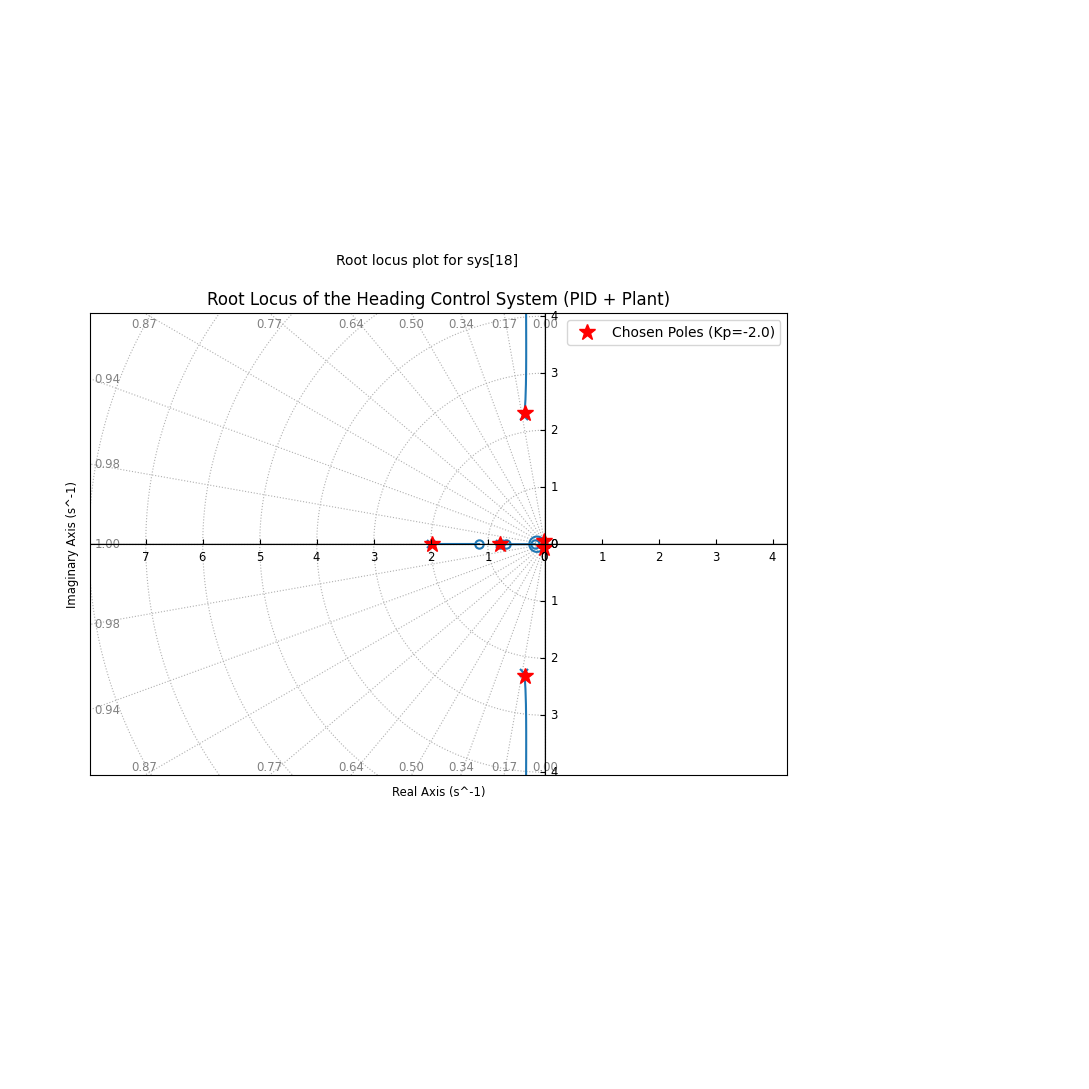

In [9]:
sys_ol = cnt.ss(A, B, C_ctrl, D_ctrl)
sys_siso = sys_ol[1, 0] 

H_r = cnt.ss2tf(sys_siso)
H_psi = H_r * cnt.tf([1], [1, 0]) 

Kp = -2.0; Ki = -0.3; Kd = -1.5; tau_f = 0.5
C_pid = cnt.tf([Kp], [1]) + cnt.tf([Ki], [1, 0]) + cnt.tf([Kd, 0], [tau_f, 1])

# Plotting the Root Locus
Kp_mag = abs(Kp)
Ki_norm = abs(Ki) / Kp_mag
Kd_norm = abs(Kd) / Kp_mag

C_shape = cnt.tf([1], [1]) + cnt.tf([Ki_norm], [1, 0]) + cnt.tf([Kd_norm, 0], [tau_f, 1])
L_shape = C_shape * (-1 * H_psi)

plt.figure(figsize=(9, 6))
rlist, klist = cnt.root_locus(L_shape, plot=True, grid=True)
cl_poles = cnt.poles(cnt.feedback(L_shape * Kp_mag, 1))

my_point, = plt.plot(np.real(cl_poles), np.imag(cl_poles), 'r*', markersize=12, label=f'Chosen Poles (Kp={Kp})')

plt.title('Root Locus of the Heading Control System (PID + Plant)')
plt.xlabel('Real Axis (s^-1)')
plt.ylabel('Imaginary Axis (s^-1)')

plt.legend(handles=[my_point])

plt.tight_layout()
plt.show()

## 4. Full Non-Linear 20/20 Zig-Zag Simulation (Q5)

We now test our three controllers (LQR, PID, MPC) onto the full, non-linear system, and we introduce:
* **Actuator Limits:** Slew rates and hard caps on rudder angles.
* **Sensor Noise:** Gaussian noise applied to speed, yaw, and yaw rate readings.
* **Environmental Disturbances:** Ocean currents pushing diagonally and wind forces acting asymmetrically on the hull.

In [10]:
def ship_dynamics(state, delta_real, n_cmd, t):
    u, v, r, x, y, psi = state
    nu = np.array([u, v, r])

    tau_1 = rho * n_cmd ** 2 * Dp_prime ** 4 * KT_prime
    tau_2 = -Y_delta_prime * delta_real
    tau_3 = -N_delta_prime * delta_real
    tau_control = np.array([tau_1, tau_2, tau_3])

    R = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi), np.cos(psi), 0],
        [0, 0, 1]
    ])

    current_speed = env["current_speed"] + env["current_speed_amp"] * np.sin(env["current_speed_freq"] * t)
    v_current_earth = np.array([*vec_from_mag_dir(current_speed, env["current_dir_deg"]), 0.0])
    nu_r = nu - R.T @ v_current_earth
    u_r, v_r, r_r = nu_r

    wind_force = env["wind_force"] + env["wind_force_amp"] * np.sin(env["wind_force_freq"] * t)
    tau_wind_body = R.T @ np.array([*vec_from_mag_dir(wind_force, env["wind_dir_deg"]), 0.0])
    tau_env = np.array([tau_wind_body[0], tau_wind_body[1], env["wind_yaw_arm"] * tau_wind_body[1]])

    M_matrix = np.array([
        [m_prime - Xu_dot_prime, 0, 0],
        [0, m_prime - Yv_dot_prime, -Yr_dot_prime],
        [0, -Nv_dot_prime, Iz_prime - Nr_dot_prime]
    ])
    N_matrix = np.array([
        [Xu_prime + Xuu_prime * np.abs(u_r), 0, 0],
        [0, Yv_prime + Yvv_prime * np.abs(v_r), (m_prime - Xu_dot_prime) * u_r + Yr_prime * np.abs(v_r)],
        [0, -(m_prime - Xu_dot_prime) * u_r + Nv_prime * np.abs(v_r), Nr_prime + Nrr_prime * np.abs(r_r)]
    ])

    eta_dot = R @ nu + v_current_earth
    nu_dot = np.linalg.solve(M_matrix, tau_control + tau_env - N_matrix @ nu_r)
    return np.concatenate((nu_dot, eta_dot))

# Setup
dt = 0.1
time_sim = np.arange(0, 1000, dt)
n_steps = len(time_sim)

# Realistic Disturbances
env["current_speed"] = 0.05
env["current_dir_deg"] = 45.0
env["wind_force"] = 0.1
env["wind_dir_deg"] = -30.0

states_lqr, states_pid, states_mpc = [np.zeros((n_steps, 6)) for _ in range(3)]
for s in (states_lqr, states_pid, states_mpc): s[0] = [2.0, 0, 0, 0, 0, 0]

zz_angle = np.deg2rad(20.0)
zz_threshold = zz_angle * 0.95
zz_ref_lqr = zz_ref_pid = zz_ref_mpc = zz_angle

zz_ref_history_lqr, zz_ref_history_pid, zz_ref_history_mpc = [np.zeros(n_steps) for _ in range(3)]
delta_real_lqr_hist, delta_real_pid_hist, delta_real_mpc_hist = [np.zeros(n_steps) for _ in range(3)]
delta_lqr_hist, n_lqr_hist = np.zeros(n_steps), np.zeros(n_steps)
delta_pid_hist, n_pid_hist = np.zeros(n_steps), np.zeros(n_steps)
delta_mpc_hist, n_mpc_hist = np.zeros(n_steps), np.zeros(n_steps)

delta_real_lqr = delta_real_pid = delta_real_mpc = 0.0
T_R = 2.0
max_slew_rate = np.deg2rad(5.0)

# Noise
noise_std_u = 0.05
noise_std_r = np.deg2rad(0.5)
noise_std_psi = np.deg2rad(1.0)

x_hat_lqr = np.array([2.0, 0.0, 0.0])
delta_cmd_lqr_prev, n_cmd_lqr_prev = 0.0, float(n0_val)
r_filtered_pid, e_int_pid = 0.0, 0.0

for i in range(1, n_steps):
    current_t = i * dt

    # ------------------ LQR ------------------
    u_lqr, v_lqr, r_lqr, _, _, psi_lqr = states_lqr[i - 1]
    y_noisy = np.array([u_lqr, r_lqr]) + np.random.normal(0, [noise_std_u, noise_std_r])
    psi_noisy_lqr = psi_lqr + np.random.normal(0, noise_std_psi)

    # Observer
    delta_u_cmd = np.array([delta_cmd_lqr_prev, n_cmd_lqr_prev - float(n0_val)])
    x_hat_dev = x_hat_lqr - np.array([2.0, 0, 0])
    dx_hat = A @ x_hat_dev + B @ delta_u_cmd + L_obs @ (y_noisy - np.array([2.0, 0]) - C_ctrl @ x_hat_dev)
    x_hat_lqr = x_hat_dev + dx_hat * dt + np.array([2.0, 0, 0])
    
    # Zig-Zag logic
    if zz_ref_lqr > 0 and psi_noisy_lqr >= zz_threshold: zz_ref_lqr = -zz_angle
    elif zz_ref_lqr < 0 and psi_noisy_lqr <= -zz_threshold: zz_ref_lqr = zz_angle
    zz_ref_history_lqr[i] = zz_ref_lqr

    # Control
    r_ref_lqr = 1.5 * (zz_ref_lqr - psi_noisy_lqr)
    u_ctrl_lqr = -K_lqr @ np.array([x_hat_lqr[0] - 2.0, x_hat_lqr[1], x_hat_lqr[2] - r_ref_lqr])
    delta_cmd_lqr_prev = np.clip(u_ctrl_lqr[0], -np.deg2rad(35), np.deg2rad(35))
    n_cmd_lqr_prev = max(0.1, float(n0_val) + u_ctrl_lqr[1])

    delta_real_lqr += np.clip((delta_cmd_lqr_prev - delta_real_lqr)/T_R, -max_slew_rate, max_slew_rate) * dt
    delta_real_lqr_hist[i], delta_lqr_hist[i], n_lqr_hist[i] = delta_real_lqr, delta_cmd_lqr_prev, n_cmd_lqr_prev
    states_lqr[i] = states_lqr[i - 1] + ship_dynamics(states_lqr[i - 1], delta_real_lqr, n_cmd_lqr_prev, current_t) * dt

    # ------------------ PID ------------------
    u_pid, v_pid, r_pid, _, _, psi_pid = states_pid[i - 1]
    psi_noisy_pid = psi_pid + np.random.normal(0, noise_std_psi)
    r_noisy_pid = r_pid + np.random.normal(0, noise_std_r)
    r_filtered_pid = 0.15 * r_noisy_pid + 0.85 * r_filtered_pid

    if zz_ref_pid > 0 and psi_noisy_pid >= zz_threshold: zz_ref_pid = -zz_angle
    elif zz_ref_pid < 0 and psi_noisy_pid <= -zz_threshold: zz_ref_pid = zz_angle
    zz_ref_history_pid[i] = zz_ref_pid

    e_pid = zz_ref_pid - psi_noisy_pid
    e_int_pid = np.clip(e_int_pid + e_pid * dt, -np.deg2rad(15)/abs(-0.05), np.deg2rad(15)/abs(-0.05))
    
    delta_cmd_pid = np.clip(-1.8*e_pid - 0.05*e_int_pid - 1.5*(-r_filtered_pid), -np.deg2rad(35), np.deg2rad(35))
    n_cmd_pid = float(n0_val)

    delta_real_pid += np.clip((delta_cmd_pid - delta_real_pid)/T_R, -max_slew_rate, max_slew_rate) * dt
    delta_real_pid_hist[i], delta_pid_hist[i], n_pid_hist[i] = delta_real_pid, delta_cmd_pid, n_cmd_pid
    states_pid[i] = states_pid[i - 1] + ship_dynamics(states_pid[i - 1], delta_real_pid, n_cmd_pid, current_t) * dt

    # ------------------ MPC ------------------
    u_mpc, v_mpc, r_mpc, _, _, psi_mpc = states_mpc[i-1]
    psi_noisy_mpc = psi_mpc + np.random.normal(0, noise_std_psi)
    
    if zz_ref_mpc > 0 and psi_noisy_mpc >= zz_threshold: zz_ref_mpc = -zz_angle
    elif zz_ref_mpc < 0 and psi_noisy_mpc <= -zz_threshold: zz_ref_mpc = zz_angle
    zz_ref_history_mpc[i] = zz_ref_mpc

    def wrap_angle(angle): return (angle + np.pi) % (2 * np.pi) - np.pi
    r_ref_mpc = 1.5 * wrap_angle(zz_ref_mpc - psi_noisy_mpc)
    x_dev_mpc = np.array([u_mpc + np.random.normal(0, noise_std_u) - 2.0, v_mpc, r_mpc + np.random.normal(0, noise_std_r)])
    
    u_ctrl_mpc = mpc_control(x_dev_mpc, np.array([0.0, 0.0, r_ref_mpc]), Ad, Bd, Q_mpc, R_mpc, P_mpc, Np, umin_mpc, umax_mpc)
    n_cmd_mpc = max(0.1, float(n0_val) + u_ctrl_mpc[1])

    delta_real_mpc += np.clip((u_ctrl_mpc[0] - delta_real_mpc)/T_R, -max_slew_rate, max_slew_rate) * dt
    delta_real_mpc_hist[i], delta_mpc_hist[i], n_mpc_hist[i] = delta_real_mpc, u_ctrl_mpc[0], n_cmd_mpc
    states_mpc[i] = states_mpc[i-1] + ship_dynamics(states_mpc[i-1], delta_real_mpc, n_cmd_mpc, current_t) * dt

### Visualizing the Maneuver and Performance Metrics

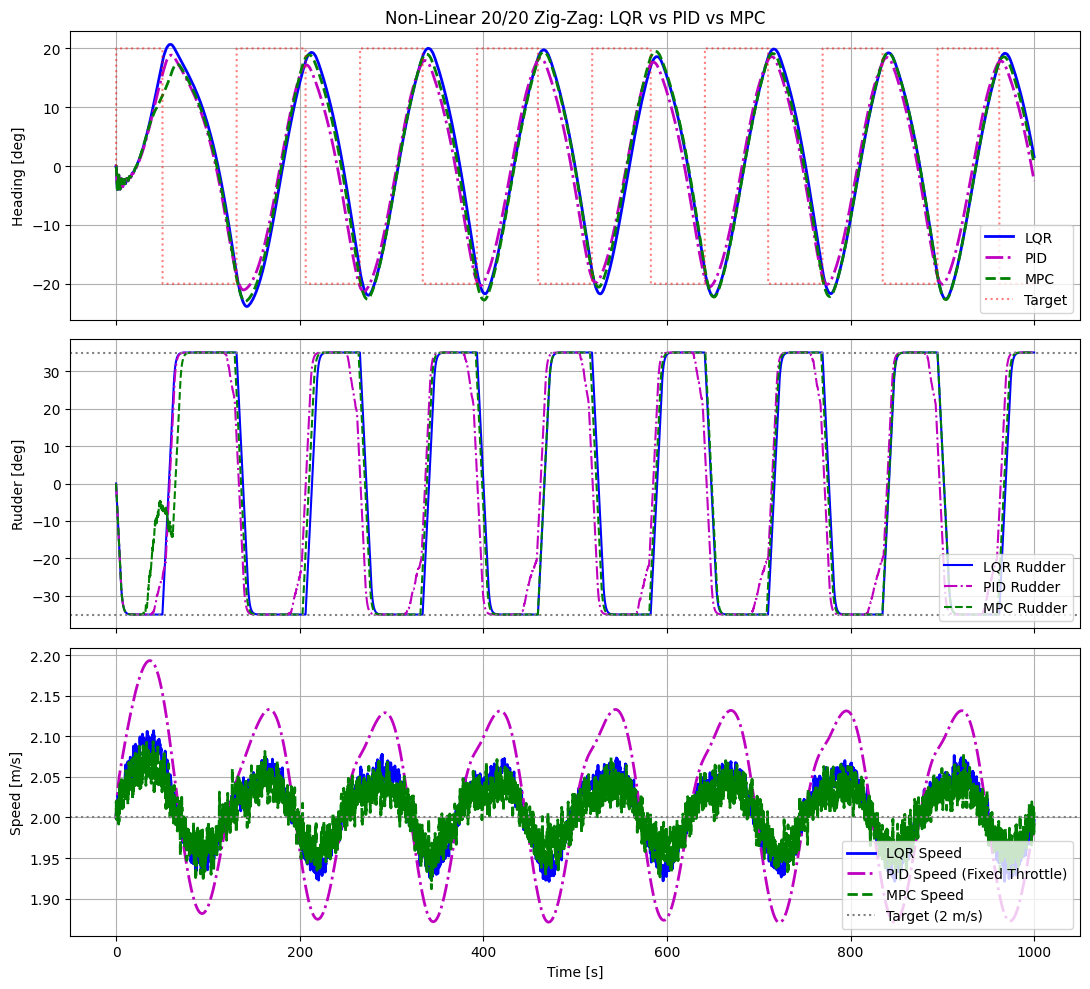

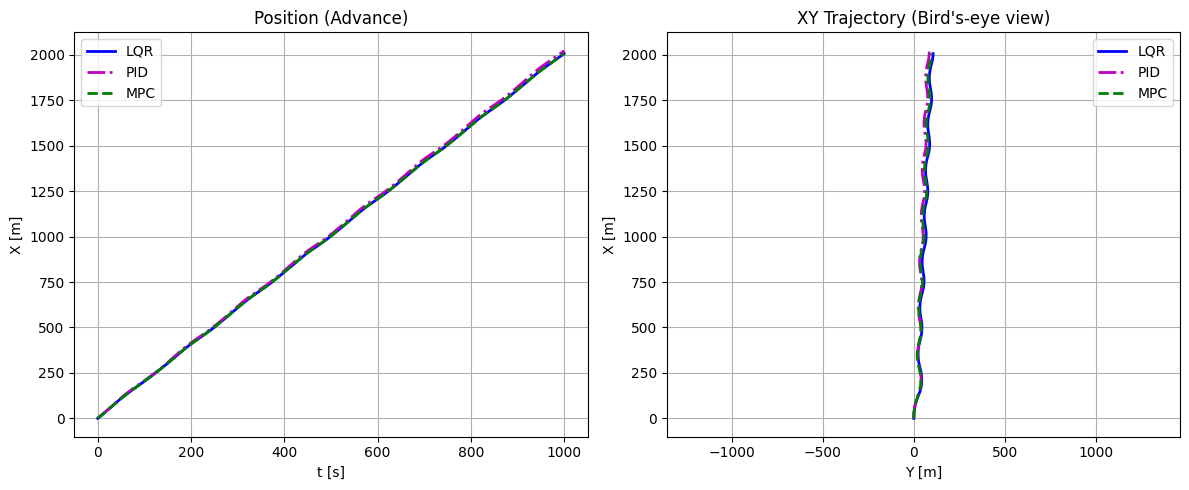


--- Control Strategy Optimization Metrics ---
Metric                         | LQR          | PID          | MPC         
---------------------------------------------------------------------------
IAE [deg*s]                    | 25846.70     | 24528.53     | 25680.55    
Control Effort [deg*s]         | 34996.50     | 33145.46     | 34498.72    
---------------------------------------------------------------------------


In [11]:
# Plot Time-Series
fig, axs = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

axs[0].plot(time_sim, np.rad2deg(states_lqr[:, 5]), label='LQR', color='b', linewidth=2)
axs[0].plot(time_sim, np.rad2deg(states_pid[:, 5]), label='PID', color='m', linewidth=2, linestyle='-.')
axs[0].plot(time_sim, np.rad2deg(states_mpc[:, 5]), label='MPC', color='g', linewidth=2, linestyle='--')
axs[0].plot(time_sim, np.rad2deg(zz_ref_history_lqr), label='Target', color='r', linestyle=':', alpha=0.5)
axs[0].set(ylabel='Heading [deg]', title='Non-Linear 20/20 Zig-Zag: LQR vs PID vs MPC')
axs[0].legend(loc='lower right'); axs[0].grid()

axs[1].plot(time_sim, np.rad2deg(delta_real_lqr_hist), label='LQR Rudder', color='b')
axs[1].plot(time_sim, np.rad2deg(delta_real_pid_hist), label='PID Rudder', color='m', linestyle='-.')
axs[1].plot(time_sim, np.rad2deg(delta_real_mpc_hist), label='MPC Rudder', color='g', linestyle='--')
axs[1].axhline(35, color='gray', linestyle=':'); axs[1].axhline(-35, color='gray', linestyle=':')
axs[1].set(ylabel='Rudder [deg]'); axs[1].legend(loc='lower right'); axs[1].grid()

axs[2].plot(time_sim, states_lqr[:, 0], label='LQR Speed', color='b', linewidth=2)
axs[2].plot(time_sim, states_pid[:, 0], label='PID Speed (Fixed Throttle)', color='m', linewidth=2, linestyle='-.')
axs[2].plot(time_sim, states_mpc[:, 0], label='MPC Speed', color='g', linewidth=2, linestyle='--')
axs[2].axhline(2.0, color='gray', linestyle=':', label='Target (2 m/s)')
axs[2].set(xlabel='Time [s]', ylabel='Speed [m/s]'); axs[2].legend(loc='lower right'); axs[2].grid()

plt.tight_layout(); plt.show()

# Plot Trajectories
fig2, axs2 = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ax1_2, ax2_2 = axs2

ax1_2.plot(time_sim, states_lqr[:, 3], label='LQR', color='b', linewidth=2)
ax1_2.plot(time_sim, states_pid[:, 3], label='PID', color='m', linewidth=2, linestyle='-.')
ax1_2.plot(time_sim, states_mpc[:, 3], label='MPC', color='g', linewidth=2, linestyle='--')
ax1_2.set(xlabel='t [s]', ylabel='X [m]', title='Position (Advance)')
ax1_2.legend(); ax1_2.grid()

ax2_2.plot(states_lqr[:, 4], states_lqr[:, 3], label='LQR', color='b', linewidth=2)
ax2_2.plot(states_pid[:, 4], states_pid[:, 3], label='PID', color='m', linewidth=2, linestyle='-.')
ax2_2.plot(states_mpc[:, 4], states_mpc[:, 3], label='MPC', color='g', linewidth=2, linestyle='--')
ax2_2.set(xlabel='Y [m]', ylabel='X [m]', title='XY Trajectory (Bird\'s-eye view)')
ax2_2.axis('equal'); ax2_2.legend(); ax2_2.grid()

fig2.tight_layout(); plt.show()

# Calculate and Print Performance Metrics
iae_lqr = np.sum(np.abs(np.rad2deg(zz_ref_history_lqr - states_lqr[:, 5]))) * dt
iae_pid = np.sum(np.abs(np.rad2deg(zz_ref_history_pid - states_pid[:, 5]))) * dt
iae_mpc = np.sum(np.abs(np.rad2deg(zz_ref_history_mpc - states_mpc[:, 5]))) * dt

effort_lqr = np.sum(np.abs(np.rad2deg(delta_lqr_hist))) * dt
effort_pid = np.sum(np.abs(np.rad2deg(delta_pid_hist))) * dt
effort_mpc = np.sum(np.abs(np.rad2deg(delta_mpc_hist))) * dt

print("\n--- Control Strategy Optimization Metrics ---")
print(f"{'Metric':<30} | {'LQR':<12} | {'PID':<12} | {'MPC':<12}")
print("-" * 75)
print(f"{'IAE [deg*s]':<30} | {iae_lqr:<12.2f} | {iae_pid:<12.2f} | {iae_mpc:<12.2f}")
print(f"{'Control Effort [deg*s]':<30} | {effort_lqr:<12.2f} | {effort_pid:<12.2f} | {effort_mpc:<12.2f}")
print("-" * 75)

## 6. Simple Physics-Informed Neural Network (PINN)

As a small extension, we solve a simplified ship yaw model with a Physics-Informed Neural Network (PINN).

We use the first-order Nomoto model:

$$T \dot{r}(t) + r(t) = K \delta(t)$$
$$\dot{\psi}(t) = r(t)$$


Where:
- $r(t)$ = yaw rate
- $\psi(t)$ = heading
- $\delta(t)$ = rudder input
- $T, K$ = Nomoto parameters

Instead of integrating the ODE directly, a neural network learns $r(t)$ and $\psi(t)$ while being penalized when it violates the physics.

Epoch    0 | Loss = 1.113698
Epoch  500 | Loss = 0.006457


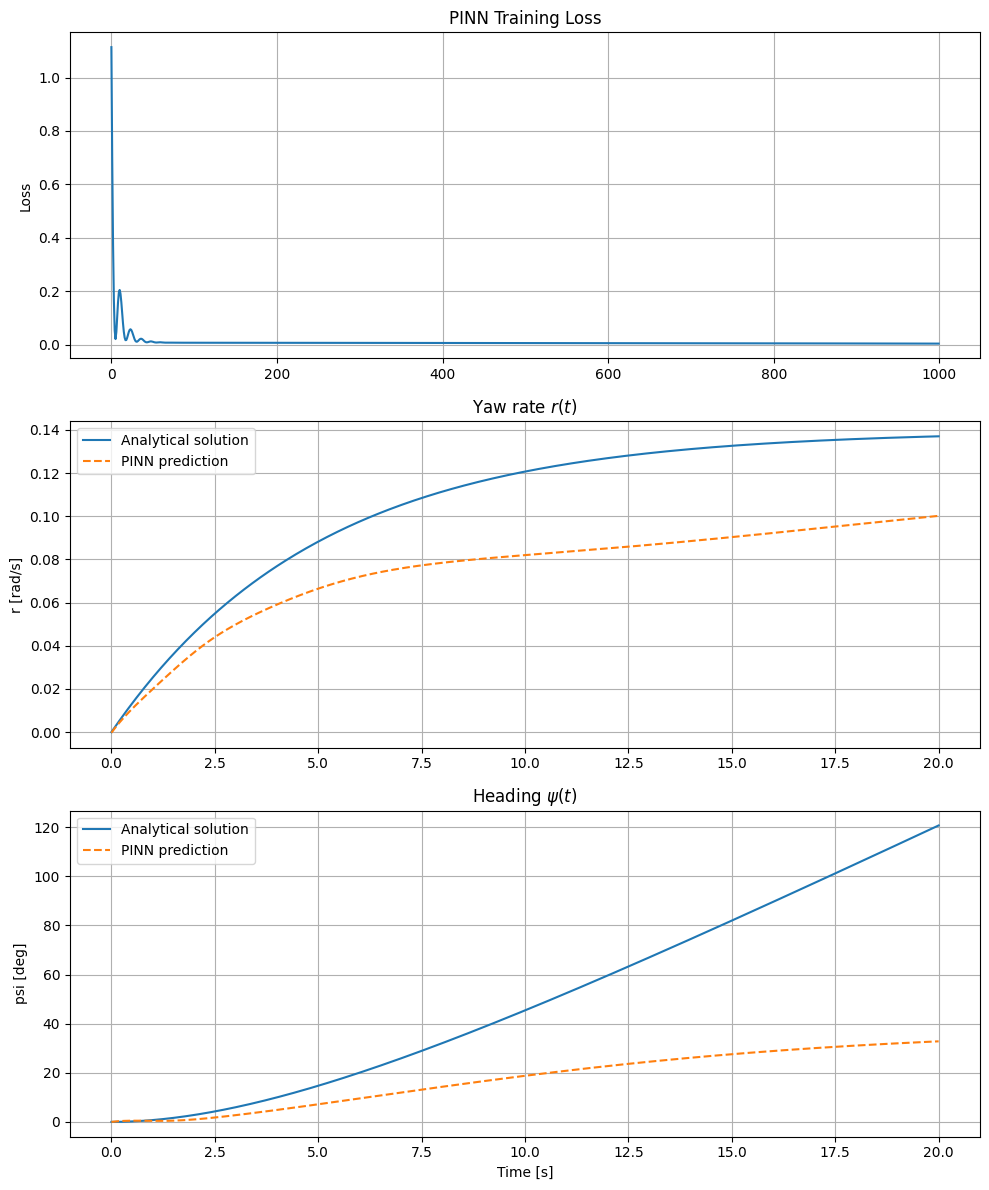

In [12]:
import torch
import torch.nn as nn

torch.manual_seed(0)

# ------------------------------------------------------------
# 1. Simplified ship model parameters
# ------------------------------------------------------------
T_nomoto = 5.0                 # time constant
K_nomoto = 0.8                 # rudder gain
delta_deg = 10.0               # constant rudder step input [deg]
delta0 = np.deg2rad(delta_deg) # [rad]
t_end = 20.0

# ------------------------------------------------------------
# 2. Define the neural network
#    Input : time t
#    Output: [r(t), psi(t)]
# ------------------------------------------------------------
class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 2)
        )

    def forward(self, t):
        return self.net(t)

model = SimplePINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 3. Rudder input function
# ------------------------------------------------------------
def rudder_input(t):
    # constant step input
    return delta0 * torch.ones_like(t)

# ------------------------------------------------------------
# 4. Training points in time
# ------------------------------------------------------------
n_phys = 200
t_phys_base = torch.linspace(0.0, t_end, n_phys).view(-1, 1)

# ------------------------------------------------------------
# 5. Training loop
#    The loss has two parts:
#    - physics loss: satisfy the ODEs
#    - initial condition loss: r(0)=0, psi(0)=0
# ------------------------------------------------------------
epochs = 1000
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()

    # make sure time tracks gradients
    t_phys = t_phys_base.clone().detach().requires_grad_(True)

    pred = model(t_phys)
    r_pred = pred[:, 0:1]
    psi_pred = pred[:, 1:2]

    # derivatives wrt time
    dr_dt = torch.autograd.grad(
        r_pred, t_phys,
        grad_outputs=torch.ones_like(r_pred),
        create_graph=True
    )[0]

    dpsi_dt = torch.autograd.grad(
        psi_pred, t_phys,
        grad_outputs=torch.ones_like(psi_pred),
        create_graph=True
    )[0]

    # Physics residuals from:
    # T * r_dot + r = K * delta
    # psi_dot = r
    res_r = T_nomoto * dr_dt + r_pred - K_nomoto * rudder_input(t_phys)
    res_psi = dpsi_dt - r_pred

    physics_loss = torch.mean(res_r**2) + torch.mean(res_psi**2)

    # Initial conditions
    t0 = torch.zeros((1, 1), requires_grad=True)
    pred0 = model(t0)
    r0_pred = pred0[:, 0:1]
    psi0_pred = pred0[:, 1:2]

    ic_loss = torch.mean(r0_pred**2) + torch.mean(psi0_pred**2)

    # Total loss
    loss = physics_loss + 20.0 * ic_loss
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss.item():.6f}")

# ------------------------------------------------------------
# 6. Evaluate the trained PINN
# ------------------------------------------------------------
t_plot = torch.linspace(0.0, t_end, 400).view(-1, 1)

with torch.no_grad():
    pred_plot = model(t_plot)
    r_pinn = pred_plot[:, 0].numpy()
    psi_pinn = pred_plot[:, 1].numpy()

t_np = t_plot[:, 0].numpy()

# ------------------------------------------------------------
# 7. Analytical solution for comparison
#    For constant delta:
#    r(t)   = K*delta*(1 - exp(-t/T))
#    psi(t) = K*delta*( t - T*(1 - exp(-t/T)) )
# ------------------------------------------------------------
r_true = K_nomoto * delta0 * (1.0 - np.exp(-t_np / T_nomoto))
psi_true = K_nomoto * delta0 * (t_np - T_nomoto * (1.0 - np.exp(-t_np / T_nomoto)))

# ------------------------------------------------------------
# 8. Plot results
# ------------------------------------------------------------
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

axs[0].plot(loss_history)
axs[0].set_title("PINN Training Loss")
axs[0].set_ylabel("Loss")
axs[0].grid(True)

axs[1].plot(t_np, r_true, label="Analytical solution")
axs[1].plot(t_np, r_pinn, "--", label="PINN prediction")
axs[1].set_title("Yaw rate $r(t)$")
axs[1].set_ylabel("r [rad/s]")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(t_np, np.rad2deg(psi_true), label="Analytical solution")
axs[2].plot(t_np, np.rad2deg(psi_pinn), "--", label="PINN prediction")
axs[2].set_title("Heading $\\psi(t)$")
axs[2].set_xlabel("Time [s]")
axs[2].set_ylabel("psi [deg]")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

The second graph compares the analytical solution and the PINN prediction for the yaw rate r(t). Both curves show the same general trend: the yaw rate increases over time and gradually approaches a steady value. This means that the PINN captures the qualitative dynamic behavior of the simplified Nomoto model. However, the PINN prediction remains below the analytical solution over the full time interval, which shows that the accuracy is still limited.

The third graph compares the analytical solution and the PINN prediction for the heading angle ψ(t). The PINN again follows the same general shape as the analytical solution, but the difference becomes much larger over time. Since heading is obtained by integrating the yaw rate, even relatively small errors in the yaw-rate prediction accumulate and produce a larger deviation in the heading response.

#### Conclusion

The results show that the PINN is able to learn the qualitative behavior of the simplified ship yaw model. The decreasing loss and the correct overall trend in both yaw rate and heading indicate that the method works in principle. However, the quantitative agreement with the analytical solution is not yet sufficient, especially for the heading angle. Therefore, these results can be considered a good first demonstration of the PINN concept, but the model would need further improvement before it can be considered accurate.